In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = (iris.target==0).astype(int)

In [4]:
per_clf = Perceptron()
per_clf.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [5]:
y_pred = per_clf.predict([[2,0.5]])

In [6]:
y_pred

array([0])

In [7]:
import tensorflow as tf
from tensorflow import keras

In [8]:
tf.__version__

'2.21.0'

In [9]:
keras.__version__

'3.13.2'

In [10]:
fashion_mist = keras.datasets.fashion_mnist

In [11]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mist.load_data()

In [12]:
X_train_full.shape

(60000, 28, 28)

In [13]:
X_train_full.dtype

dtype('uint8')

In [14]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [15]:
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [16]:
class_names[y_train[0]]

'Coat'

In [17]:
y_valid

array([9, 0, 0, ..., 5, 8, 3], shape=(5000,), dtype=uint8)

In [18]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [19]:
X_valid.shape

(5000, 28, 28)

In [20]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])),
model.add(keras.layers.Dense(300,activation="relu")),
model.add(keras.layers.Dense(100,activation="relu")),
model.add(keras.layers.Dense(10,activation="softmax"))

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
hidden1 = model.layers[1]

In [24]:
hidden1.name

'dense'

In [25]:
model.get_layer("dense")

<Dense name=dense, built=True>

In [26]:
weights, biases = hidden1.get_weights()

In [27]:
weights

array([[ 0.06075563, -0.07087436,  0.00966538, ...,  0.05248637,
        -0.00368484,  0.06693353],
       [-0.0025401 , -0.02281031,  0.07121427, ..., -0.06651727,
         0.00696741, -0.04817475],
       [-0.07180957,  0.00329876,  0.04988809, ..., -0.07302508,
        -0.00548286, -0.04633333],
       ...,
       [ 0.01998784, -0.02112853,  0.06113949, ...,  0.02372956,
         0.02393518,  0.02267399],
       [ 0.03118405, -0.06990561,  0.01661278, ...,  0.01571595,
        -0.02153604,  0.01461039],
       [-0.05258624,  0.07410285, -0.03713363, ...,  0.02254636,
        -0.00760695,  0.04206435]], shape=(784, 300), dtype=float32)

In [28]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [29]:
biases.shape

(300,)

In [30]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7646 - loss: 0.7136 - val_accuracy: 0.8254 - val_loss: 0.5107
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8293 - loss: 0.4880 - val_accuracy: 0.8374 - val_loss: 0.4731
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8449 - loss: 0.4423 - val_accuracy: 0.8580 - val_loss: 0.4176
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8546 - loss: 0.4148 - val_accuracy: 0.8678 - val_loss: 0.3870
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8594 - loss: 0.3959 - val_accuracy: 0.8674 - val_loss: 0.3852
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8673 - loss: 0.3784 - val_accuracy: 0.8706 - val_loss: 0.3728
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8707 - loss: 0.3655 - val_accuracy: 0.8704 - val_loss: 0.3710
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8741 - loss: 0.3534 - 

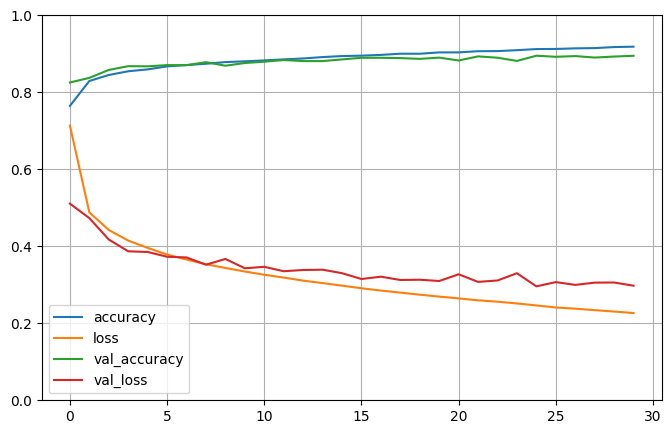

In [32]:
import pandas as pd
from matplotlib import pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [33]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8397 - loss: 67.6190


[67.61895751953125, 0.8396999835968018]

In [34]:
X_new = X_test[:3]
y_hat = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [35]:
y_hat

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [36]:
y_hat.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [37]:
y_pred = model.predict(X_new)
y_pred = y_pred.argmax(axis=-1)
np.array(class_names)[y_pred]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full)

In [40]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_valid_scaled = x_scaler.transform(X_valid)
X_test_scaled = x_scaler.transform(X_test)

In [41]:
X_train.shape

(11610, 8)

In [42]:
X_train.shape[1:]

(8,)

In [43]:
model_reg = keras.Sequential()
model_reg.add(keras.layers.Input(shape=X_train_scaled.shape[1:], name="input_layer"))
model_reg.add(keras.layers.Dense(units=100, activation="relu", name="layer_1"))
model_reg.add(keras.layers.Dense(units=50, activation="relu", name="layer_2"))
model_reg.add(keras.layers.Dense(units=1, activation=None, name="output_layer"))

In [44]:
model_reg.compile(loss="mse",optimizer="sgd",metrics=["mse"])

In [45]:
history = model_reg.fit(X_train_scaled,y_train, validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0234 - mse: 1.0234 - val_loss: 0.5271 - val_mse: 0.5271
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5703 - mse: 0.5703 - val_loss: 0.4604 - val_mse: 0.4604
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4158 - mse: 0.4158 - val_loss: 0.4200 - val_mse: 0.4200
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3957 - mse: 0.3957 - val_loss: 0.3951 - val_mse: 0.3951
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3830 - mse: 0.3830 - val_loss: 0.3956 - val_mse: 0.3956
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3732 - mse: 0.3732 - val_loss: 0.3828 - val_mse: 0.3828
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3666 - mse: 0.3666 - val_loss: 0.3730 - val_mse: 0.3730
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3577 - mse: 0.3577 - val_loss: 0.3766 - val_mse: 0.3766
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [46]:
y_hat = model_reg.predict(X_test_scaled)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


In [47]:
y_hat

array([[2.8704562],
       [0.8178342],
       [2.651535 ],
       ...,
       [2.9644036],
       [3.0465322],
       [1.072813 ]], shape=(5160, 1), dtype=float32)

In [48]:
y_test

array([2.817, 0.576, 2.724, ..., 3.76 , 2.858, 0.852], shape=(5160,))

In [49]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_hat)

In [50]:
mse

0.3498787111405382

In [51]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_,hidden2])
output = keras.layers.Dense(1, activation=None)(concat)
model_deep = keras.Model(inputs=[input_], outputs=[output])

In [52]:
model_deep.compile(loss="mse", metrics=["mse"], optimizer="adam")

In [53]:
history = model_deep.fit(X_train_scaled,y_train,validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.3051 - mse: 2.3051 - val_loss: 0.6664 - val_mse: 0.6664
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7369 - mse: 0.7369 - val_loss: 0.4787 - val_mse: 0.4787
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4861 - mse: 0.4861 - val_loss: 0.4476 - val_mse: 0.4476
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4136 - mse: 0.4136 - val_loss: 0.4188 - val_mse: 0.4188
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3923 - mse: 0.3923 - val_loss: 0.4007 - val_mse: 0.4007
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3810 - mse: 0.3810 - val_loss: 0.3962 - val_mse: 0.3962
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3754 - mse: 0.3754 - val_loss: 0.3936 - val_mse: 0.3936
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3684 - mse: 0.3684 - val_loss: 0.3954 - val_mse: 0.3954
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [54]:
input_A = keras.layers.Input(shape=[5],name="wide_input")
input_B = keras.layers.Input(shape=[6],name="deep_input")
hidden1 = keras.layers.Dense(30,name="hidden_1")(input_B)
hidden2 = keras.layers.Dense(30,name="hidden_2")(hidden1)
concat = keras.layers.Concatenate()([input_A,hidden2])
output = keras.layers.Dense(1,name="output")(concat)

model_deep_2 = keras.Model(inputs=[input_A,input_B],outputs=[output])

In [55]:
model_deep_2.compile(loss="mse",optimizer="adam")

X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]

X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

In [56]:
history = model_deep_2.fit((X_train_A,X_train_B),y_train,epochs=32,validation_data=((X_valid_A,X_valid_B),y_valid))

Epoch 1/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6009.3843 - val_loss: 9.4867
Epoch 2/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 32.4923 - val_loss: 4.8238
Epoch 3/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 26.0677 - val_loss: 4.2020
Epoch 4/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.4356 - val_loss: 4.0610
Epoch 5/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 36.4825 - val_loss: 3.3002
Epoch 6/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11.3844 - val_loss: 2.8263
Epoch 7/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7373 - val_loss: 4.4471
Epoch 8/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34.2183 - val_loss: 1.7075
Epoch 9/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.4027 - val_loss: 1.7905
Epoch 10/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12.2479 - val_loss: 1.3780
Epoch 11/32
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 357.2252 - val_loss: 1.1531
Epoch 12/32
363/363 ━━━━━━━━━━━━━━━━━━━━

In [57]:
# output = keras.layers.Dense(1,name="output")(concat)
# aux_output = keras.layers.Dense(1,name="aux_output")(hidden2)
# model = keras.Model(inputs=[input_A,input_B],outputs[output,aux_output])
# model.compile(loss=["mse","mse"], loss_weights=[0.9,0.1], optimizer="sgd"]
# history = model.fit(
# [X_train_A,X_train_B], [y_train,y_train], epochs=20, validation_data=([X_valid_A,X_valid_B]),[y_valid,y_valid]))

#total_loss, main_loss, aux_loss = model.evaluate([X_test_A,X_test,B],[y_test,y_test])

#y_pred_main, y_pred_aux = model.predict([X_new_A,X_new_B])

##DOUBLE OUTPUT HERE